In [1]:
import IJulia
import Base64

# The julia kernel has built in support for Revise.jl, so this is the 
# recommended approach for long-running sessions:
# https://github.com/JuliaLang/IJulia.jl/blob/9b10fa9b879574bbf720f5285029e07758e50a5e/src/kernel.jl#L46-L51

# Users should enable revise within .julia/config/startup_ijulia.jl:
# https://timholy.github.io/Revise.jl/stable/config/#Using-Revise-automatically-within-Jupyter/IJulia-1

# clear console history
IJulia.clear_history()

fig_width = 7
fig_height = 5
fig_format = :retina
fig_dpi = 96

# no retina format type, use svg for high quality type/marks
if fig_format == :retina
  fig_format = :svg
elseif fig_format == :pdf
  fig_dpi = 96
  # Enable PDF support for IJulia
  IJulia.register_mime(MIME("application/pdf"))
end

# convert inches to pixels
fig_width = fig_width * fig_dpi
fig_height = fig_height * fig_dpi

# Intialize Plots w/ default fig width/height
try
  import Plots

  # Plots.jl doesn't support PDF output for versions < 1.28.1
  # so use png (if the DPI remains the default of 300 then set to 96)
  if (Plots._current_plots_version < v"1.28.1") & (fig_format == :pdf)
    Plots.gr(size=(fig_width, fig_height), fmt = :png, dpi = fig_dpi)
  else
    Plots.gr(size=(fig_width, fig_height), fmt = fig_format, dpi = fig_dpi)
  end
catch e
  # @warn "Plots init" exception=(e, catch_backtrace())
end

# Initialize CairoMakie with default fig width/height
try
  import CairoMakie

  # CairoMakie's display() in PDF format opens an interactive window
  # instead of saving to the ipynb file, so we don't do that.
  # https://github.com/quarto-dev/quarto-cli/issues/7548
  if fig_format == :pdf
    CairoMakie.activate!(type = "png")
  else
    CairoMakie.activate!(type = string(fig_format))
  end
  CairoMakie.update_theme!(resolution=(fig_width, fig_height))
catch e
    # @warn "CairoMakie init" exception=(e, catch_backtrace())
end
  
# Set run_path if specified
try
  run_path = "QzpcVXNlcnNcTmlrb2xhalxHaXRcZ3JhcGgtZXF1aWxpYnJpdW0tcmFkaWF0aXZlLXRyYW5zZmVyXGV4YW1wbGVz"
  if !isempty(run_path)
    run_path = String(Base64.base64decode(run_path))
    cd(run_path)
  end
catch e
  @warn "Run path init:" exception=(e, catch_backtrace())
end


# emulate old Pkg.installed beahvior, see
# https://discourse.julialang.org/t/how-to-use-pkg-dependencies-instead-of-pkg-installed/36416/9
import Pkg
function isinstalled(pkg::String)
  any(x -> x.name == pkg && x.is_direct_dep, values(Pkg.dependencies()))
end

# ojs_define
if isinstalled("JSON") && isinstalled("DataFrames")
  import JSON, DataFrames
  global function ojs_define(; kwargs...)
    convert(x) = x
    convert(x::DataFrames.AbstractDataFrame) = Tables.rows(x)
    content = Dict("contents" => [Dict("name" => k, "value" => convert(v)) for (k, v) in kwargs])
    tag = "<script type='ojs-define'>$(JSON.json(content))</script>"
    IJulia.display(MIME("text/html"), tag)
  end
elseif isinstalled("JSON")
  import JSON
  global function ojs_define(; kwargs...)
    content = Dict("contents" => [Dict("name" => k, "value" => v) for (k, v) in kwargs])
    tag = "<script type='ojs-define'>$(JSON.json(content))</script>"
    IJulia.display(MIME("text/html"), tag)
  end
else
  global function ojs_define(; kwargs...)
    @warn "JSON package not available. Please install the JSON.jl package to use ojs_define."
  end
end


# don't return kernel dependencies (b/c Revise should take care of dependencies)
nothing


In [2]:
using RayTraceHeatTransfer, GLMakie, StatsBase

xy = [0.0 0.0; 1.0 0.0; 2.0 0.0; 2.0 1.0;
      1.0 1.0; 0.0 1.0; 1.0 2.0; 0.0 2.0]
points = vcat(hcat(xy, zeros(8)), hcat(xy, ones(8)))   # z = 0 then z = 1

faces = [ 1  2  5  6;  2  3  4  5;  6  5  7  8;    # 1–3   z = 0 caps
          9 10 13 14; 10 11 12 13; 14 13 15 16;    # 4–6   z = 1 caps
          1  2 10  9;  2  3 11 10;  3  4 12 11;    # 7–9   sides, 9 = x-arm end
          4  5 13 12;  5  7 15 13;  7  8 16 15;    # 10–12 sides, 12 = y-arm end
          8  6 14 16;  6  1  9 14]                 # 13–14 sides

Ndim = 11
domainL = RayTracingDomain3D_surfaces(points, faces, Ndim,
              zeros(14), [fill(1000.0, 3); zeros(3); fill(-1.0, 8)], ones(14));

In [3]:
#| echo: false
Makie.inline!(true)   # draw figures into the page rather than a window

true

┌ Warning: Found `resolution` in the theme when creating a `Scene`. The `resolution` keyword for `Scene`s and `Figure`s has been deprecated. Use `Figure(; size = ...` or `Scene(; size = ...)` instead, which better reflects that this is a unitless size and not a pixel resolution. The key could also come from `set_theme!` calls or related theming functions.
└ @ Makie C:\Users\Nikolaj\.julia\packages\Makie\frKXt\src\scenes.jl:264


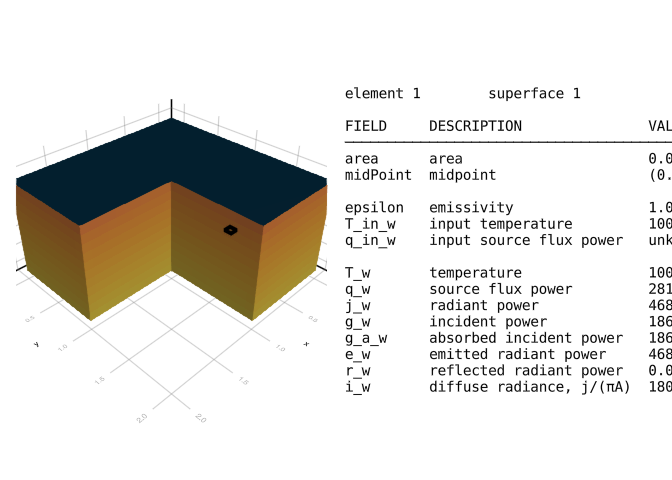

In [4]:
domainL(10^8; verbose = false)     # total rays, divided across the 1694 elements
smooth!(domainL; verbose = false)
solveEquilibrium!(domainL, domainL.F_smooth; verbose = false)

# Zoom into the duct and inspect the reentrant corner from within:
fig  = Figure(size = (1200, 700))
ax   = LScene(fig[1, 1], scenekw = (camera = cam3d!, show_axis = true))
info = Label(fig[1, 2], ""; tellheight = false, tellwidth = true,
             halign = :left, justification = :left,
             fontsize = 14, font = "DejaVu Sans Mono") # with info as in Example 6
colsize!(fig.layout, 2, Relative(0.5))
plotMesh(ax, domainL; field = :T, inspect = true, label = info)
DataInspector(fig)
fig